<div class = "alert alert-block alert-info"> 

# Algorithme DIVISER pour REGNER
    
# La multiplication    
    
## Problématique    
    

Réaliser des multiplications de très grand nombre qui dépassent la capacité de calcul du micro-processeur.
    
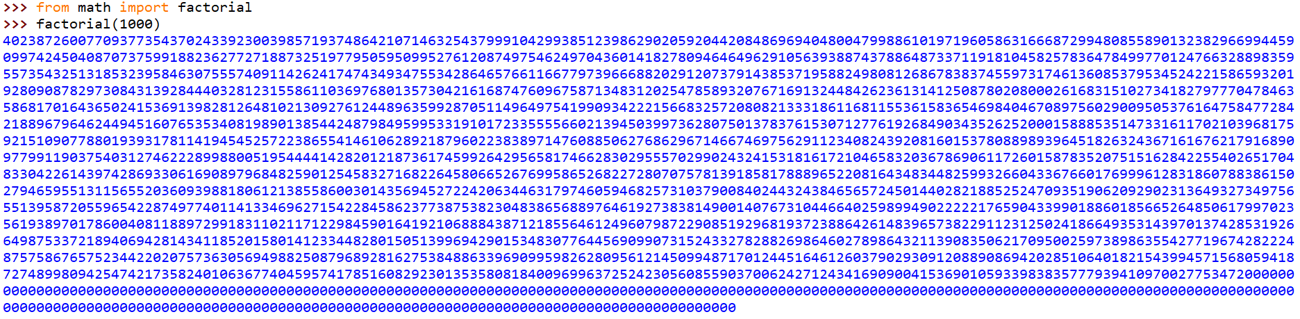    
    
## Multiplication naïve

Pour multiplier deux nombres de $n$ chiffres, la méthode naïve multiplie chaque chiffre du multiplicateur par chaque chiffre du multiplicande. Cela exige donc $n^2$ produits de deux chiffres. 

Le temps de calcul est en $O(n²)$. On ne compte ici que les multiplications : l’opération la plus gourmande en temps.
    
***Exemple :*** Ici, 2 nombre de 4 chiffres : 16 multiplications élémentaires

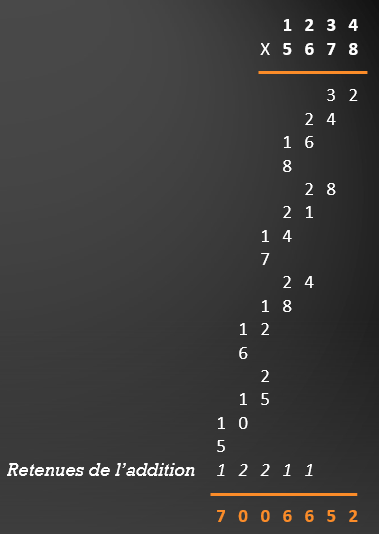    
    
***Cet algorithme est inutilisable dans le calcul des très grands nombres. Les temps de calculs deviennent rédibitoires.***
    
## Algorithme de Karatsuba  
    
Anatoli Alekseïevitch Karatsouba (en russe : Анатолий Алексеевич Карацуба) est un mathématicien soviétique puis russe né le 31 janvier 1937 à Grozny et mort le 28 septembre 2008 à Moscou. 
   
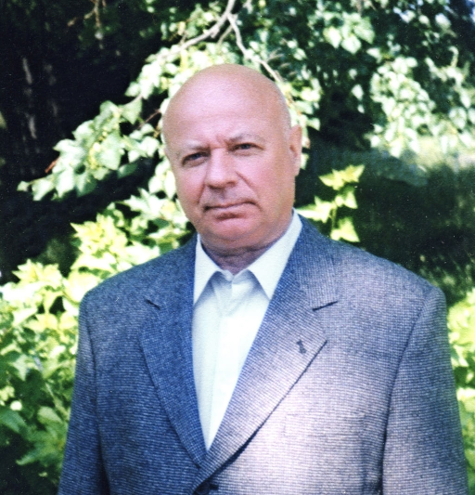
    
### Le principe  
 
soit $M$ et $N$ deux nombres à plusieurs chiffres. On peut décomposer $M$ et $N$ de la façon suivante :
    
$$M = a\cdot10^k+b$$
et 
$$N = c\cdot10^k+d$$
Par exemple :
$$1234 = 12\cdot10^2+34$$

***Karatsuba*** a montré que le produit $M\cdot N$ peut alors s'écrire :
$$M\cdot N = (𝑎\cdot10^𝑘+𝑏)\cdot(𝑐\cdot10^𝑘+𝑑)=𝑎𝑐\cdot10^{2𝑘}+(𝑎𝑐+𝑏𝑑−(𝑎−𝑏)\cdot(𝑐−𝑑))\cdot10^𝑘+𝑏𝑑$$
$$M\cdot N = t_1\cdot10^{2𝑘}+(t_1+t_2−t_3)\cdot10^𝑘+t_2$$
qui comporte seulement 3 produits : 
- $t_1 = a \cdot c$
- $t_2 = b \cdot d$
- $t_3 = (𝑎 − 𝑏) \cdot (𝑐 − 𝑑)$

    
### Application récursive  
    
On peut appliquer récursivement ce principe jusqu'à obtenir des nombres de 1 chiffre dont la multiplication est élémentaire.   
    
***Exempe :*** $1234\cdot5678$ 

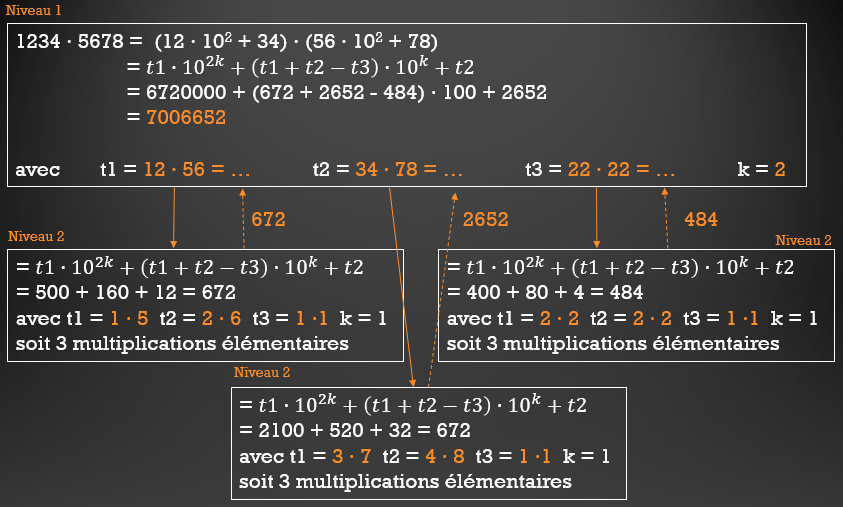
    
Au total, il faut ***9 multiplications élémentaires*** pour calculer ce produit au lieu de 16 !  
    
### L'algorithme  


On peut en déduire l'algorithme suivant :  
    
```python
def mul_Kara(M, N):

    if taille(M) = 1 and taille(N) = 1:
        #régner
        return M * N

    else :
        #diviser
        k = taille(M) / 2
        décomposer M et N en a, b, c, d de k chiffres
        t1 = mul_Kara(a, c)
        t2 = mul_Kara(b, d)
        t3 = mul_Kara(a - b, c - d)

        #recombiner
        return t1 * 10^2k + (t1 + t2 - t3) * 10^k + t2
```       

### Complexité

La complexité de cet algorithme est en $O(n^{1.585})$ au lieu de $O(n^2)$ pour l’algorithme naïf.


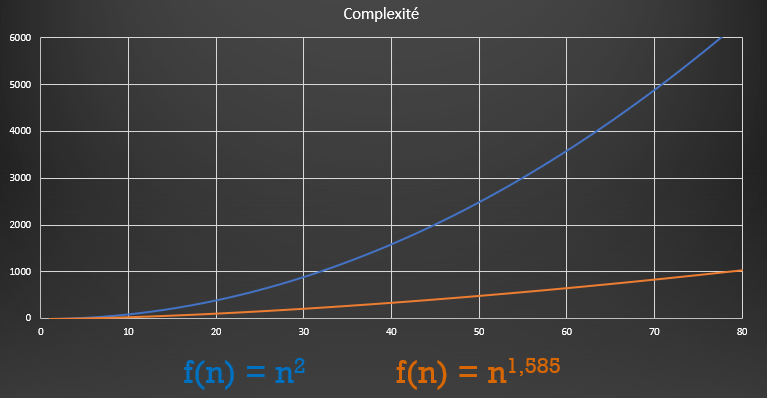

</div>

<div class = "alert alert-block alert-warning">

## Les fonctions élémentaires

### Les fonctions de conversion


Pour appliquer cet algorithme facilement, on présente les nombres sous forme d’une liste de chiffre, poids faible en tête :  
    
$$123456 \; s'écrit \ alors \; [6, 5, 4, 3, 2, 1]$$
    
Les fonctions de conversion permettent de passer d'une forme à l'autre.


Ecrivez les fonctions **`conv(x)`** et **`conv_ inv(lst)`** qui assure les conversions d’un nombre vers une liste de chiffre et inversement.   
Ces fonctions doivent obligatoirement être écritent de façon **récursive**.

In [ ]:
from doctest import run_docstring_examples

In [ ]:
def conv(x) :
    """
    Conversion d'un entier x de n chiffre en décimal
    vers une liste de n élément. Chaque élément étant un chiffre de 0 à 9.
    La liste est remplie Poids faible en tête
    
    Tests automatiques:
    >>> conv(12345)
    [5, 4, 3, 2, 1]
    >>> conv(0)
    [0]
    >>> conv(1000)
    [0, 0, 0, 1]
    """
    ...

In [ ]:
conv(12345)

In [ ]:
run_docstring_examples(conv, globals())  

In [ ]:
def conv_inv(lst):
    """
    Conversion d'une liste de n élément. Chaque élément étant un chiffre de 0 à 9.
    vers un entier x de n chiffre en décimal.
    La liste est remplie Poids faible en tête
    
    Tests automatiques:
    >>> conv_inv([5, 4, 3, 2, 1])
    12345
    >>> conv_inv([0])
    0
    >>> conv_inv([0, 0, 0, 1])
    1000
    """
    ...

In [ ]:
conv_inv([5, 4, 3, 2, 1])

In [ ]:
run_docstring_examples(conv_inv, globals())  

<div class = "alert alert-block alert-warning">

### Fonctions de mise en forme des listes


Pour faciliter la suite, il est nécessaire de concevoir des fonctions qui ajoute ou retire des zéros sur les listes sans modifier la valeur des nombres en question.

- retirer des zéros inutiles : 
    $$000322 = 322$$
    $$[2, 2, 3, 0, 0, 0] = [2, 2, 3]$$
- ajouter des zéros pour normaliser la taille de deux listes.
    
Ecrivez la fonction **`meme_len(lst1, lst2)`** qui reçoit en arguments deux listes de chiffres et ajoute autant de zéro que nécessaire à la plus petite des listes pour que leurs tailles soit identiques. Evidemment la valeur des listes n’est pas modifiée.    
    
</div>

In [ ]:
def meme_len(l1, l2):
    """
    Compare la longueur des deux listes l1 et l2.
    Ajoute des zéros (en poids fort donc sans changer la valeur du nombre global
    a l'une ou l'autre des listes pour que les deux aient la même longueur.
    
    tests automatiques
    >>> a = [5, 4, 3, 2, 1]
    >>> b = [1]
    >>> meme_len(a, b)
    >>> a
    [5, 4, 3, 2, 1]
    >>> b
    [1, 0, 0, 0, 0]
    >>> b = [0, 0, 0, 0, 0, 0, 0, 1]
    >>> meme_len(a,b)
    >>> a
    [5, 4, 3, 2, 1, 0, 0, 0]
    >>> b
    [0, 0, 0, 0, 0, 0, 0, 1]
    """
    ...

In [ ]:
a = [5, 4, 3, 2, 1]
b = [1]
meme_len(a, b)
b

In [ ]:
run_docstring_examples(meme_len, globals())  

<div class = "alert alert-block alert-warning">

Ecrivez une fonction **supp_zero(lst)** qui supprime les zéros inutiles sans changer la valeur de la liste de nombre passée en argument.

In [ ]:
def supp_zero(lst):
    """
    Suppression des 0 en poids fort
    dans la liste lst qui est modifiée par cette fonction
    tests automatiques
    >>> a = [5, 4, 3, 2, 1, 0, 0, 0]
    >>> supp_zero(a)
    >>> a
    [5, 4, 3, 2, 1]
    >>> b = [1, 0, 0, 0, 0]
    >>> supp_zero(b)
    >>> b
    [1]
    >>> c = [0, 0, 0, 0, 0]
    >>> supp_zero(c)
    >>> c
    [0]
    """
    ...

In [ ]:
b = [1, 2, 0, 0, 0]
supp_zero(b)
b

In [ ]:
run_docstring_examples(supp_zero, globals())  

<div class = "alert alert-block alert-warning">

### Fonctions de calcul élémentaire  

Il est nécessaire de redéfinir les opérations élémentaires :  
    
    

- addition : 
    $$[9, 9, 9, 9] + [1] = [0, 0, 0, 0, 1]$$
- soustraction : 
    $$[2, 2, 3, 4, 5] - [1, 2, 3, 4, 5] = [1]$$
- comparaison : 
    $$[2, 2, 3, 4, 5] > [1, 2, 3, 4, 5]$$
    

#### Addition  
Ecrire la fonction **`add(lst1, lst2)`** qui renvoi la somme de deux listes de chiffre. 

In [ ]:
def add(lst1, lst2):
    """
    Addition des deux nombres lstA et lstB sous forme de liste de chiffre, poids faible en tête.
    lstA et lstB ne sont pas modifiées par la fonction
    retourne le résultat sous forme d'une liste
    
    Tests automatiques
    >>> a = [2, 5]
    >>> b = [9, 2]
    >>> add(a,b)
    [1, 8]
    >>> a = [8, 9, 9, 9]
    >>> b = [1]
    >>> add(a,b)
    [9, 9, 9, 9]
    >>> a
    [8, 9, 9, 9]
    >>> b
    [1]
    >>> a = [9, 9, 9, 9]
    >>> b = [1]
    >>> add(a,b)
    [0, 0, 0, 0, 1]
    >>> a
    [9, 9, 9, 9]
    >>> b
    [1]
    >>> a = [5, 4, 3, 2, 1]
    >>> b = [5, 6, 7, 8, 9]
    >>> add(a,b)
    [0, 1, 1, 1, 1, 1]
    >>> a
    [5, 4, 3, 2, 1]
    >>> b
    [5, 6, 7, 8, 9]
    """
    ...

In [ ]:
a = [8, 9, 9, 9]
b = [1]
add(a,b)

In [ ]:
a = [9, 9, 9, 9]
b = [1]
add(a,b)

In [ ]:
run_docstring_examples(add, globals())  

<div class = "alert alert-block alert-warning">

#### Comparaison  
Ecrivez la fonction **`plus_grand(lst1, lst2)`** qui renvoi True si `lst1` est plus grand ou égale à `lst2` et False sinon.

In [ ]:
def plus_grand(lst1, lst2):
    """
    Compare les valeurs de lst1 et lst2
    si lst1 >= lst2 retourne True
    sinon, retourne False
    
    Tests automatiques
    >>> a = [1, 2, 3, 4, 5]
    >>> b = [1, 2, 3, 4, 5]
    >>> plus_grand(a, b)
    True
    >>> b = [2, 2, 3, 4, 5]
    >>> plus_grand(a, b)
    False
    >>> plus_grand(b, a)
    True
    >>> a = [7, 7, 3, 1, 3]
    >>> b = [3, 0, 4, 3, 9]
    >>> plus_grand(b, a)
    True
    """
    ...

In [ ]:
a = [1, 7, 3, 1, 3]
b = [2, 7, 3, 1, 3]
plus_grand(b, a)

In [ ]:
b = [5, 4]
a = [0]
plus_grand(b, a)

In [ ]:
run_docstring_examples(plus_grand, globals())  

<div class = "alert alert-block alert-warning">

#### Soustraction  
On donne la fonction **`sub(lst1, lst2)`** qui renvoi la différence de deux listes de chiffre. lst1 étant supérieur ou égal à lst2.

In [ ]:
def sub(lst1, lst2):
    """Renvoie lst1 - lst2 sans modifier lst1 et lst2.
    La méthode utilisée est celle des soustractions posées comme a l'école primaire
    
    Tests automatiques
    >>> a = [2, 2, 3, 4, 5]
    >>> b = [1, 2, 3, 4, 5]
    >>> sub(a, b)
    [1]
    >>> b = [1]
    >>> a = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
    >>> sub(a, b)
    [9, 9, 9, 9, 9, 9, 9, 9, 9]
    """
    l1 = lst1[:]
    l2 = lst2[:]
    meme_len(l1, l2)
    retenue = 0
    result = []
    
    ...

In [ ]:
b = [1]
a = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
sub(a, b)

In [ ]:
b = [1]
a = [1]
sub(a, b)

In [ ]:
b = [2]
a = [1]
sub(a, b)

In [ ]:
run_docstring_examples(sub, globals())  

<div class = "alert alert-block alert-warning">

## La fonction de Karastuba

Ecrivez la fonction **`mul_Kara(lst1, lst2)`** qui réalise la multiplication de deux listes de chiffre en utilisant l’algorithme de Karastuba. **`lst1`** et **`lst2`** ne sont pas modifiées. Cette fonction est programmée récursivement. Le résultat est renvoyé sous forme d’une liste de chiffre.

In [ ]:
def mul_Kara(lst1, lst2):
    """Multiplication des deux listes lst1 et lst2 avec la méthode de KARATSUBA
    Fonctions récursive qui ne modifie pas lst1 et lst2.
    """
    global compt_mul
    # copie les listes pour ne pas les modifier
    l1 = lst1[:]
    l2 = lst2[:]
    # ajuste les longueurs des listes éventuellement
    meme_len(l1, l2)
    
    ...



??? question Un peu d'aide
Une version a trous :

```python
def mul_Kara(lst1, lst2):
    """Multiplication des deux listes lst1 et lst2 avec la méthode de KARATSUBA
    Fonctions récursive qui ne modifie pas lst1 et lst2.
    """
    global compt_mul
    # copie les listes pour ne pas les modifier
    l1 = lst1[:]
    l2 = lst2[:]
    # ajuste les longueurs des listes éventuellement
    meme_len(l1, l2)
    
    # condition d'arrêt
    # les listes ont un seul éléments
    ...
        
    # les listes ont plus que 1 élément
    # on les coupe en deux
    ...

    # on applique ensuite Karatsuba sur les 4 parties
    t1 = ...
    t2 = ...

    # t3 = (a - b) * (c - d) = t31 * t32
    # attention au signe, le résultat peut être négatif
    sign = 1 # on démarre avec un signe +
    ...
    
    t3 = ...

    # t = t1 + t2 - t3
    # selon signe de t3
    if sign > 0:
        t = ...
    else:
        t = ...
    # on a tout pour calculer le résultat
    # t1 * 10^2k + (t1 + t2 - t3) * 10^k + t2
    # t1 * 10^2k = [0] * 2 * k + ac on ajoute 2k 0 en poids faible
    # t = (t1 + t2 - t3)
    # donc t * 10^k = [0] * k + t on ajoute k 0 en poids faible
    # reste plus qu'à ajouter t2 et on peut retourner le résultat
    res = ...

    supp_zero(res)
    
    return res
```
???

Un exemple pour tester :

In [ ]:
a = 1234567890123456789012345678909999999912659845589961469813613131313131361368874655441588556585
b = 9876543210987654321098765432100000000000002256622541258562555855654555215254438542435435435435
res = a * b

print('n vaut', max((len(str(a)), len(str(b)))))

res

In [ ]:
compt_mul = 0
mul_Kara(conv(a), conv(b))

Modifier cette fonctions pour calculer le nombre de multiplications élémentaires de cet algorithme. Puis, exécutez la cellule ci-dessous pour compter le nombres de multiplications réalisées.

In [ ]:
global compt_mul
compt_mul = 0

res1 = mul_Kara(conv(a), conv(b))
assert conv_inv(res1) == res, "Résultat faux"

print(compt_mul, "multiplications élémentaires")

<div class = "alert alert-block alert-info"> 

## Comparaison avec la multiplication naïve

### Complexité

La complexité de cet algorithme est en $O(n^{1.585})$ au lieu de $O(n^2)$ pour l’algorithme naïf.


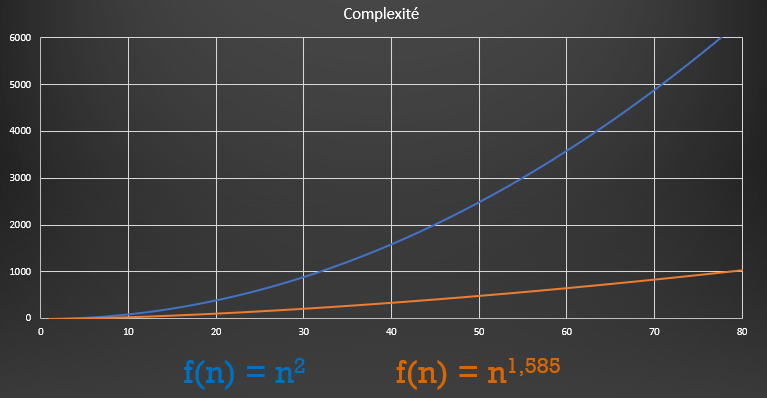
    
Voici la fonction **`mul_naive(lst1, lst2)`** qui réalise la multiplication des deux listes de chiffre avec l’algorithme naïf.

In [ ]:
def mul_naive(lA, lB):
    """Multiplication naive (comme a l'école primaire) entre les deux listes lA et lB.
    Renvoi le résultat et ne modifie pas les les listes lA et lB
    
    """
    l1 = lA[:]
    l2 = lB[:]
    #pour compter le nombre de multiplication élémentaire
    global compt_mul
    
    res = []   # matrice des multiplications chiffre par chiffre
    for i in range(len(l1)):
        # pour chaque chiffre de l1 : l1[i]
        # que l'on multiplie par l2
        # le résultat est une liste qu'on ajoute dans res
        r = 0   # retenue nulle au début
        res.append([0] * i)    # on décale d'un cran a chaque chiffre de l1, comme on met des points à l'école ...
        for j in range(len(l2)):
            compt_mul += 1
            result = l1[i] * l2[j] + r
            res[i].append(result % 10)    # le chiffre des unité va au résultat
            r = result // 10    # celui des dizaine part en retenue
        if r != 0:
            # si il reste une reteune a la fin, on l'ajoute. ça fera un chiffre de plus en poids fort
            res[i].append(r)
    
    result = []    # resultat final
    for i in range(len(res)):
        result = add(result, res[i])
        
    return result

Modifier cette fonctions pour calculer le nombre de multiplications élémentaires de cet algorithme. Puis, exécutez la cellule ci-dessous pour comparer les deux algorithmes.

In [ ]:
global compt_mul
compt_mul = 0

res2 = mul_naive(conv(a), conv(b))
assert conv_inv(res2) == res, "Résultat faux"

print(compt_mul, "multiplications élémentaires")

#### Pour lancer tous les tests automatiques et vérifier le fonctionnement

In [ ]:
import doctest
doctest.testmod()